In [3]:
from hybrid_joint import *
from diffrax import *
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from controls import *

In [4]:
H = 0.1
M = 1
grid_points = 10000000
kappa = 1
T = 1.
print(T/grid_points)

1e-07


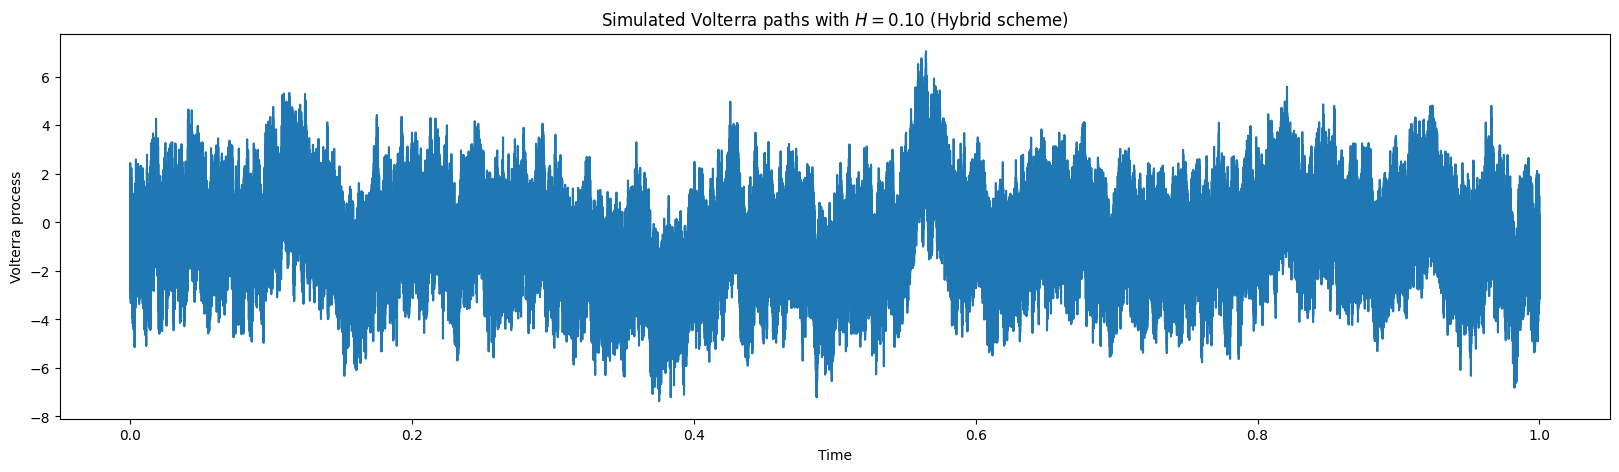

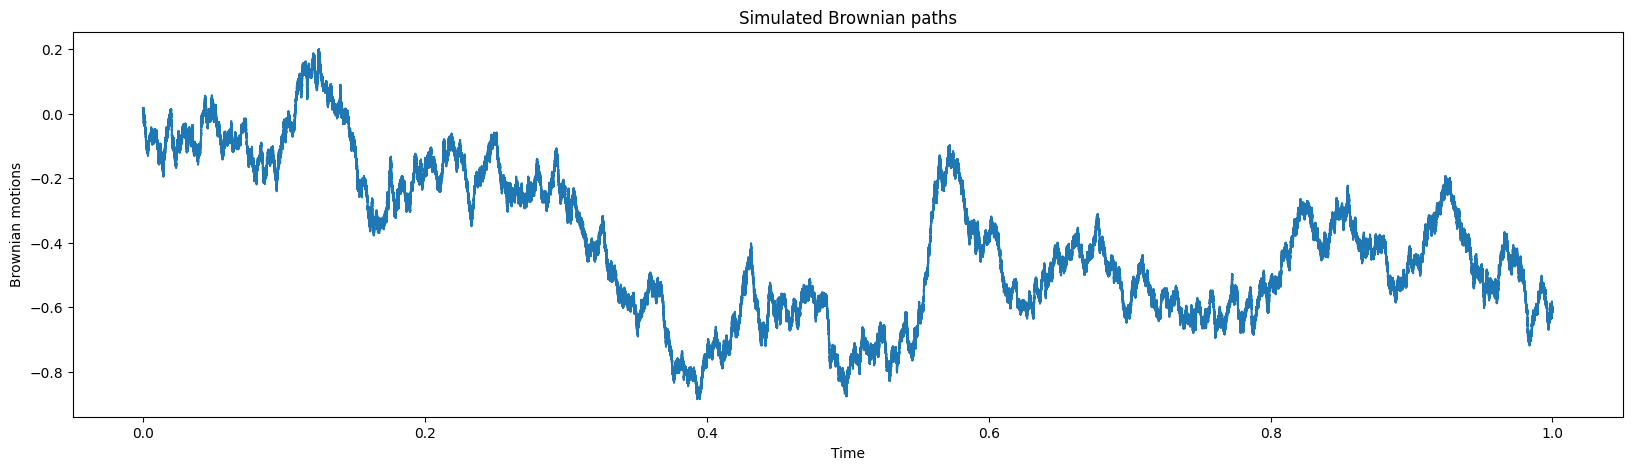

In [5]:
fBmpath, Bmpath = hybrid_scheme(grid_points, M, T, H, kappa)
fine_times = np.linspace(0,T,grid_points)

plt.figure(figsize=(20, 5))
for i in range(M):
    plt.plot(fine_times,fBmpath[i,:]) 
    
plt.xlabel('Time')
plt.ylabel('Volterra process')
plt.title('Simulated Volterra paths with $H=%1.2f$ (Hybrid scheme)'%H)
plt.show()


plt.figure(figsize=(20, 5))
for i in range(M):
    plt.plot(fine_times,Bmpath[i,:]) 
    
    
plt.xlabel('Time')
plt.ylabel('Brownian motions')
plt.title('Simulated Brownian paths')
plt.show()

In [39]:
# Now that we have our "true noise", here are the parameters for subsampling from it
epsilon = 0.00001
every_nth_pt = int(grid_points*epsilon)
times = jnp.arange(0, 1, epsilon)

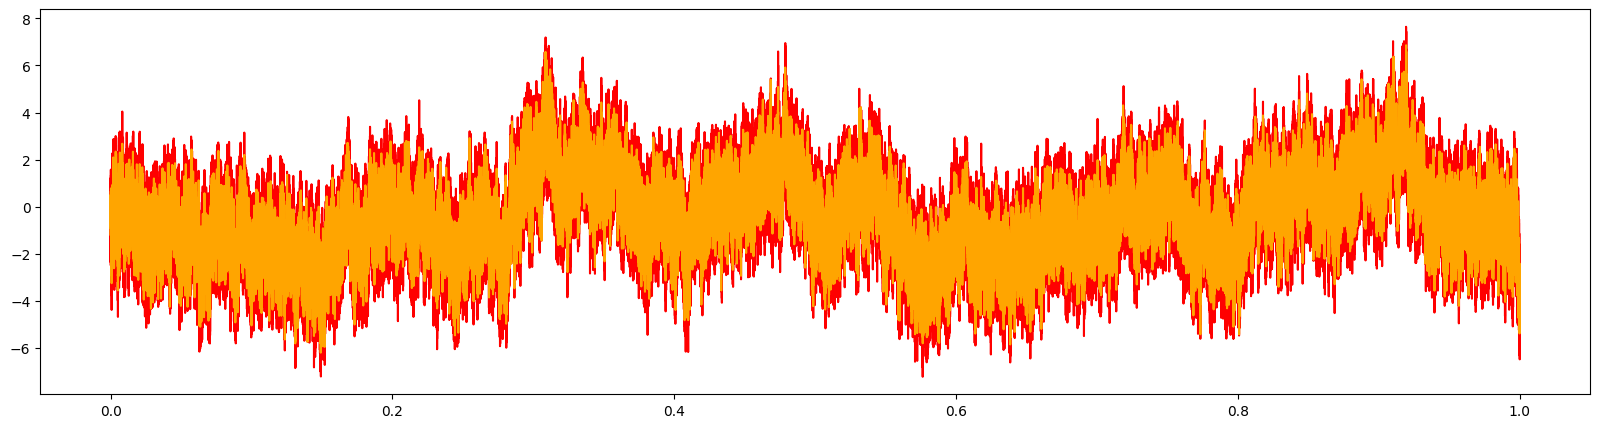

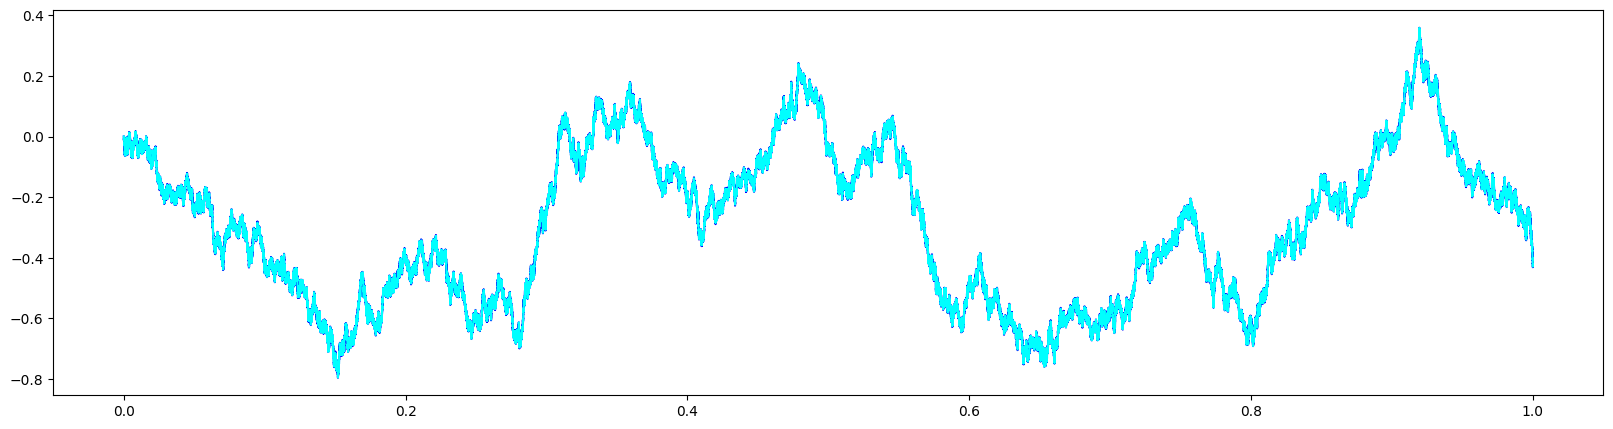

In [40]:
# Create the controls
subsampled_Bmpath = Bmpath[:, ::every_nth_pt]
bm_interp = LinearInterpolation(times, subsampled_Bmpath[0,:])
bm_interp = evaluate_and_reshape(bm_interp.evaluate)

# Create the fbm control
subsampled_fBmpath = fBmpath[:, ::every_nth_pt]
fbm_interp = LinearInterpolation(times, subsampled_fBmpath[0,:])
fbm_interp = evaluate_and_reshape(fbm_interp.evaluate)

# check that they are similar to the original
plt.figure(figsize=(20, 5))
plt.plot(fine_times, fBmpath[0,:], color = 'red')
plt.plot(times, subsampled_fBmpath[0,:], color = 'orange')

# check that they are similar to the original
plt.figure(figsize=(20, 5))
fine_times = jnp.linspace(0, 1, grid_points)
plt.plot(fine_times, Bmpath[0,:], color = 'blue')
plt.plot(times, subsampled_Bmpath[0,:], color = 'cyan')

Quadratic rough Heston model - RDE version

$$ \begin{cases}\mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d}W_t - \frac 12 S_t(a(Z_t - b)^2 + c) \mathrm{d}t \\ \mathrm{d}Z_t = \lambda \theta(t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d} W^H_t \end{cases} $$

with $\theta$ some function chosen to match the VIX futures? Check this is the same as solving $V$ first and then taking the exponential martingale.

$$S_t = \exp\bigg(\int_0^t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W - \frac 12 \int_0^t (a(Z_t - b)^2 + c) \mathrm{d}t \bigg) $$


In [43]:
# Quadratic rough Heston model

# Model parameters
a = 1
b = 0.5
c = 1

theta = 2
lam = 0.2
eta = 1

solver_epsilon = 0.01*epsilon
lag = 1.2*epsilon
saveat = SaveAt(ts = times)

y0 = jnp.array([1, 1])

drift_qrh_ll = lambda t, y, args: jnp.array([-(1/2) * y[0] * ( a * jnp.square(y[1]-b) + c ), lam*(theta - y[1])]) # note the classical Ito-Strat correction in the price
diffusion_qrh_ll = lambda t, y, args: jnp.array([[ 0, y[0] * jnp.sqrt( a * jnp.square( y[1] - b )+ c ) ], [ lam * eta * jnp.sqrt( a * jnp.square( y[1] - b )+ c ), 0 ]])

lagged_fbm_control = lagged_control(lambda t: fbm_interp(0,t), lag)
lead_lag_control = join_controls(lagged_fbm_control, bm_interp)

terms = MultiTerm(ODETerm(drift_qrh_ll), ControlTerm(diffusion_qrh_ll, lead_lag_control))

solutions_ll = diffeqsolve(terms, Euler(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

In [37]:
# go back up and coarsen the epsilon, also coarsen the solver_epsilon
solver_epsilon = 0.1*epsilon
solutions_ll_coarser = diffeqsolve(terms, Euler(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

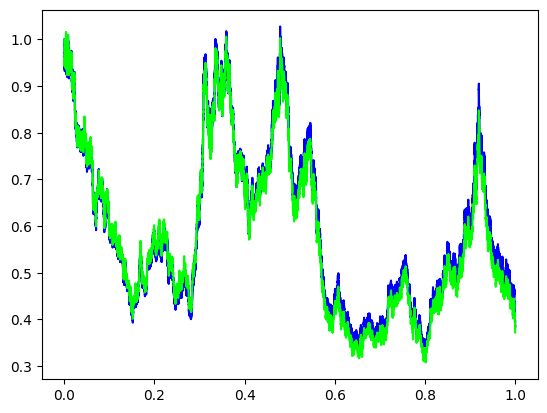

In [44]:
plt.plot(solutions_ll.ts[:], solutions_ll.ys[:, 0], color = "blue")
#plt.plot(solutions_ll.ts[:], solutions_ll.ys[:, 1], color = "red") # I won't plot the vol - it's a bit wild

plt.plot(solutions_ll_coarser.ts[:], solutions_ll_coarser.ys[:, 0], color = "lime")

# pretty good convergence along both the fbm and solver mesh. More testing necessary


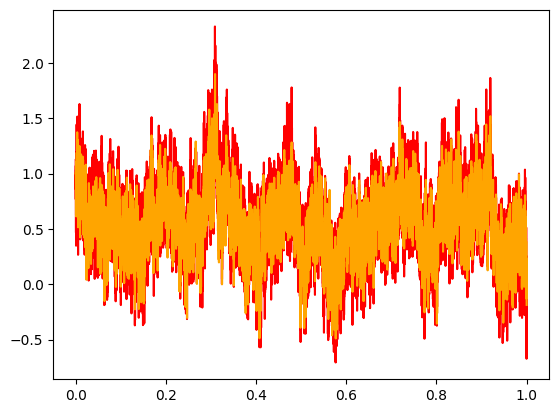

In [13]:
# let's look at what the vol looks like on different scales/solver meshes

plt.plot(solutions_ll.ts[:], solutions_ll.ys[:, 1], color = "red")
plt.plot(solutions_ll_coarser.ts[:], solutions_ll_coarser.ys[:, 1], color = "orange")

# there is a resemblance. Probably the best we can hope for


In [20]:
# Now let's check identity with exponential martingale

# We solve the vol on its own

y0 = jnp.array([1])
times = jnp.arange(0, 1, epsilon)
solver_epsilon = 0.01*epsilon

drift_qrh_vol = lambda t, y, args: jnp.array([lam*(theta - y[1])]) 
diffusion_qrh_vol = lambda t, y, args: jnp.array([ lam * eta * jnp.sqrt( a * jnp.square( y[1] - b )+ c )])

terms = MultiTerm(ODETerm(drift_qrh_vol), ControlTerm(diffusion_qrh_vol, lagged_fbm_control))
solution_vol = diffeqsolve(terms, Euler(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

In [21]:
Z = LinearInterpolation(times, solution_vol.ys[:,0]).evaluate #create the vol process

y0 = jnp.array([0,0])

drift_qrh_price = lambda t, y, args: jnp.array([-(1/2) * ( a * jnp.square(Z(t) - b) + c ), 0])
diffusion_qrh_price = lambda t, y, args: jnp.array([[jnp.sqrt(a * jnp.square(Z(t) - b) + c)],[1]])
terms = MultiTerm(ODETerm(drift_qrh_price), ControlTerm(diffusion_qrh_price, bm_interp))
integral_price = diffeqsolve(terms, Euler(), 0, 1, dt0 = epsilon, max_steps=None, y0=y0, saveat=saveat) # note solver has to have size epsilon for this to be Ito
exp_martingale = jnp.exp(integral_price.ys[:,0])


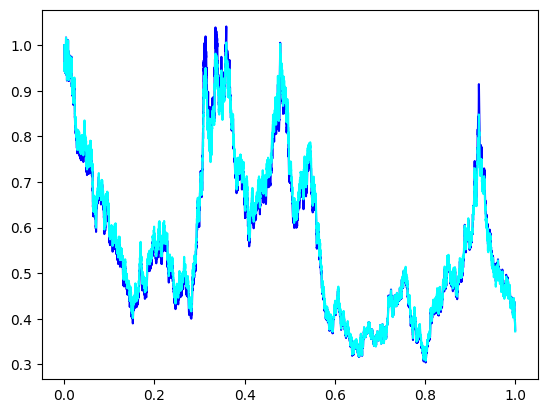

In [22]:
plt.plot(integral_price.ts[:], exp_martingale[:], color = "blue")
plt.plot(solutions_ll.ts[:], solutions_ll.ys[:, 0], color = "cyan")

# very close match

So to sum up: epsilon = 0.0001 and solver_epsilon = 0.1*epsilon is acceptable, but epsilon = 0.00001 and solver_epsilon = 0.01*epsilon is better. The first configuration is quite fast. More testing is necessary.